# **Spam Email Classification**

This project aims to build a machine learning model to classify emails as **spam** or **ham (not spam)** using text message data.
We will create an ensemble of multiple models to combine predictions. 

Outline:

-   Cleaning the data
-   Preprocessing 
-   Visualization
-   Train/Test split
-   Training and Evaluating Models

In [128]:
# Data Manipulation and Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning - Preprocessing
from sklearn.preprocessing import MinMaxScaler # Feature normalization

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Evaluation
from sklearn.metrics import classification_report

# Natural Language Processing (NLP)
import nltk # Natural language tool-kit
import spacy
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet # Stopwords and WordNet for lexical resources
from nltk.stem import WordNetLemmatizer # Lemmatizer for reducing words to their base form

# Splitting into sets
from sklearn.model_selection import train_test_split, GridSearchCV

In [82]:
# Download NLTK resources
nltk.download("wordnet")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abbas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abbas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abbas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\abbas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### **Cleaning the Datasets**

In [83]:
df_1 = pd.read_csv("spam_data.csv")
df_1.head()

,CATEGORY,MESSAGE,FILE_NAME
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978
4,1,This is the bottom line. If you can GIVE AWAY...,00033.9babb58d9298daa2963d4f514193d7d6


In [84]:
df_2 = pd.read_csv("spam.csv", encoding="ISO-8859-1")
df_2.head()

,Message,Class
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [85]:
# Dropping useless column from first dataset
df_1.drop(columns=["FILE_NAME"], inplace=True)

# Renaming columns
df_1.rename(columns={
    "MESSAGE": "Message",
    "CATEGORY": "Label"
}, inplace=True)

In [86]:
# Changing labels to 0 or 1
df_2["Class"] = df_2["Class"].apply(lambda x: 1 if str(x) == "spam" else 0)

# Renaming columns
df_2.rename(columns={
    "Class": "Label"
}, inplace=True)

In [87]:
df_1.head()

,Label,Message
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ..."
1,1,ATTENTION: This is a MUST for ALL Computer Use...
2,1,This is a multi-part message in MIME format.\n...
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...
4,1,This is the bottom line. If you can GIVE AWAY...


In [88]:
df_2.head()

,Message,Label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [89]:
# Merge the two together
data = pd.concat([df_1, df_2], ignore_index=True)

### **Preprocessing**

In [90]:
# First get a list of common english words that have no significant meaning.
stopwords = stopwords.words("english")

# These terms might be included in the text, but are typically not relevant to the analysis
html_tokens = [
    "font", "td", "br", "size", "b", "tr", "p", "face", "color", "width", "align",
    "center", "height", "table", "border", "href", "u", "html", "style", "div",
    "bgcolor", "src", "img", "value", "option", "text", "type", "span", "content",
    "body", "cellspacing", "li", "cellpadding", "blockquote", "input", "valign",
    "address", "strong", "left", "margin", "head", "order", "colspan", "title",
    "form", "tbody", "class", "alt", "meta", "link", "background", "id", "title",
    "name", "method", "action", "lang", "hidden", "submit", "padding", "document",
    "search", "server", "target", "hr", "ul", "em", "select", "small", "red",
    "plain", "option", "bordercolor", "charset", "equiv", "decoration", "label",
    "nbsp", "ptsize", "3d", "html", "-"
]

stopwords.extend(html_tokens)

In [91]:
# Load the spaCy English model
nlp = spacy.load("en_core_web_sm")

tokenizer = nltk.RegexpTokenizer(r"\w+")

# Define a function that converts a message to a list of useful tokens
def message_to_token_list(s):

    # Take a sentence and make a list of every valid word in the sentence.
    tokens = tokenizer.tokenize(s)

    # Lowercase the words
    lowercased_tokens = [t.lower() for t in tokens]

    # Lemmatize each token to get its base or root form (e.g., "running" -> "run")
    text = " ".join(lowercased_tokens)

    # Process the text using spacy
    doc = nlp(text)

    # Extract Lemmetized tokens
    lemmetized_tokens = [token.lemma_ for token in doc]

    # Remove stopwords and other irrelevant tokens (like HTML tags)
    useful_tokens = [t for t in lemmetized_tokens if t not in stopwords]

    return useful_tokens

### **Visualization**

In [92]:
# Show top 50 words that appear in spam/ham emails. Can be used to identify spam tokens.
def visualize(spam: bool):

    # Initialize empty dictionary
    token_counter = {}

    # Iterate through each row in the dataset.
    for index, row in data.iterrows():

        # Only look at rows that are spam or ham
        if row["Label"] == spam: 

            # Turn row's message into list of useful tokens
            message = message_to_token_list(row["Message"])

            # Iterate through each token. 
            for token in message: 
                if token in token_counter:
                    # Increment by 1 if token in dictionary. 
                    token_counter[token] += 1
                else:
                    # else add it to dictionary. 
                    token_counter[token] = 1
    
    # Sort the dictionary in descending order. 
    sorted_tokens = dict(sorted(token_counter.items(), key=lambda item: item[1], reverse=True))

    # Get the 50 most popular words.
    keys = list(sorted_tokens.keys())[:50]
    values = list(sorted_tokens.values())[:50]

    # Plot them
    plt.figure(figsize=(12, 6))
    plt.bar(keys, values, color="red")
    plt.xlabel("tokens")
    plt.ylabel("frequency")
    plt.xticks(rotation=55, ha="right", fontsize=10)
    if spam: plt.title(f"Histogram of Token Frequencies for Spam Emails")
    else: plt.title(f"Histogram of Token Frequencies for Ham Emails")
    plt.show

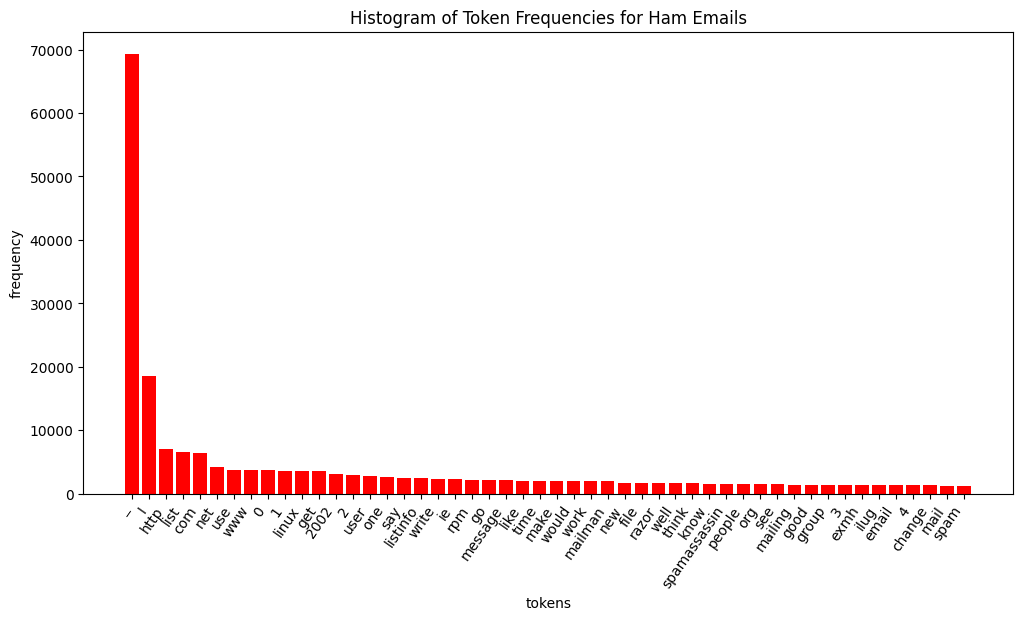

In [93]:
visualize(spam=False)

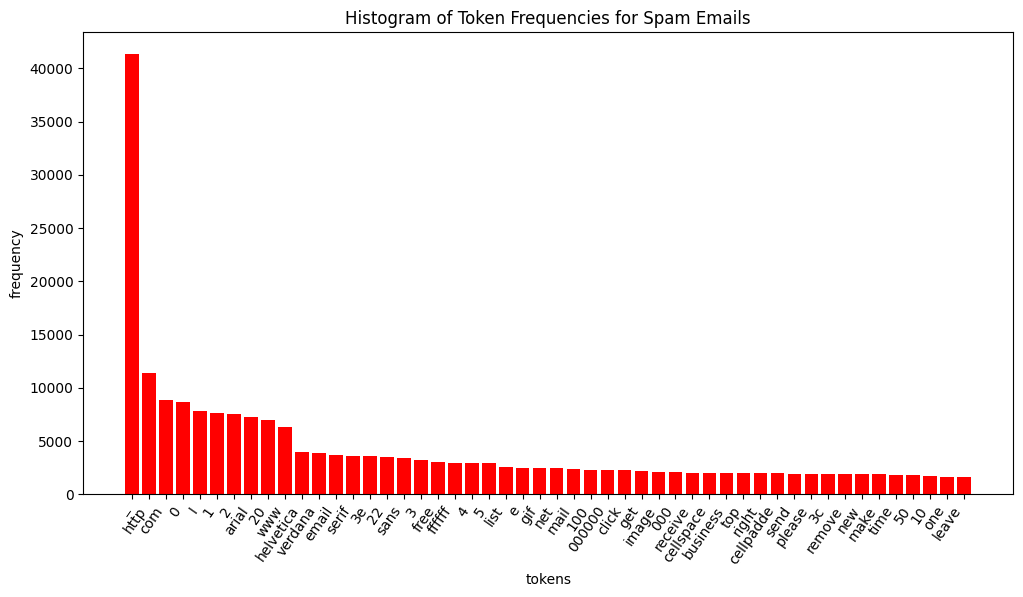

In [94]:
visualize(spam=True)

In [95]:
# Create a list of spam tokens, try to choose tokens that are in the spam email histogram, but NOT in ham email histogram. 
spam_tokens = ["helvetica", "email", "free", "list", "click", "image", "get", "please", "send", "gif"]

In [96]:
# Map tokens to indices
token_to_index_mapping = {t:i for t, i in zip(spam_tokens, range(len(spam_tokens)))}
token_to_index_mapping

{'helvetica': 0,
 'email': 1,
 'free': 2,
 'list': 3,
 'click': 4,
 'image': 5,
 'get': 6,
 'please': 7,
 'send': 8,
 'gif': 9}

In [ ]:
# Take a message and count the number of times each token appears and return a list of number of occurrences.
def message_to_count_vector(message):
    count_vector = np.zeros(len(spam_tokens))
    tokenized_message = message_to_token_list(message)

    for token in tokenized_message:
        if token in spam_tokens:
            index = token_to_index_mapping[token]
            count_vector[index] += 1
            
    return count_vector

# Example usage:
message_to_count_vector('helvetica hi click on this free gif')

array([1., 0., 1., 0., 1., 0., 0., 0., 0., 1.])

### **Train Test Split**

In [ ]:
# Shuffle the data
data = data.sample(frac=1, random_state=1)

# 80% training, 20% testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

print(train_data.shape, test_data.shape)

(9094, 2) (2274, 2)


In [102]:
def get_data_frame(data: pd.DataFrame) -> tuple[np.array, np.array]:
    """ Given a training or testing set, return two np.arrays: X which is our data matrix, and t which is our ground
        truth vector.
    """
    # Get ground truth vector
    t = data["Label"].to_numpy().astype(int)    

    message_columns = data["Message"]

    count_vectors = []

    # Go through each message in the col and obtain it's count vector
    for message in message_columns:
        count_vector = message_to_count_vector(message)

        count_vectors.append(count_vector)
    
    X = np.array(count_vectors).astype(int)

    return X, t

In [103]:
X_train, t_train = get_data_frame(train_data)
X_test, t_test = get_data_frame(test_data)

print(X_train.shape, t_train.shape, X_test.shape, t_test.shape)

(9094, 10) (9094,) (2274, 10) (2274,)


In [105]:
# Rescale the features so they are on the same scale.
scaler = MinMaxScaler().fit(X_train)

X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)

### **Training and Evaluating Models**

In [114]:
lr = LogisticRegression()
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "max_iter": [20, 30, 50, 100, 200]
}

lr_cv = GridSearchCV(lr, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
lr_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [20, 30, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

In [115]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "max_depth": [5, 10, 15],
    "n_estimators": [100, 250, 500],
    "min_samples_split": [3, 5, 10]
}

rf_cv = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
rf_cv.fit(X_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [3, 5, ...], 'n_estimators': [100, 250, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [117]:
gnb = GaussianNB().fit(X_train, t_train)

In [127]:
# Gaussian Naive Bayes
print(" Gaussian Naive Bayes: \n")
gnb_pred = gnb.predict(X_test)
print(classification_report(t_test, gnb_pred))

# Logistic Regression
print("\nLogistic Regression: \n")
lr_pred = lr_cv.predict(X_test)
print(classification_report(t_test, lr_pred))

# Random Forest
print("\nRandom Forest: \n")
rf_pred = rf_cv.predict(X_test)
print(classification_report(t_test, rf_pred))

 Gaussian Naive Bayes: 

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1740
           1       0.89      0.45      0.60       534

    accuracy                           0.86      2274
   macro avg       0.87      0.72      0.76      2274
weighted avg       0.86      0.86      0.84      2274


Logistic Regression: 

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      1740
           1       0.88      0.48      0.62       534

    accuracy                           0.86      2274
   macro avg       0.87      0.73      0.77      2274
weighted avg       0.86      0.86      0.85      2274


Random Forest: 

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1740
           1       0.86      0.60      0.70       534

    accuracy                           0.88      2274
   macro avg       0.87      0.78      0.82      2274
weighte

In [129]:
estimators = [("Naive Bayes", gnb),
              ("Logistic Regression", lr_cv.best_estimator_),
              ("Random Forest", rf_cv.best_estimator_)
              ]

stacking = StackingClassifier(estimators=estimators,
                              final_estimator=LogisticRegression(max_iter=1000))

stacking.fit(X_train, t_train)

c:\Users\abbas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('Naive Bayes', ...), ('Logistic Regression', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=1000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and so

In [130]:
stacking_pred = stacking.predict(X_test)
print(classification_report(t_test, stacking_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1740
           1       0.86      0.60      0.71       534

    accuracy                           0.88      2274
   macro avg       0.87      0.78      0.82      2274
weighted avg       0.88      0.88      0.87      2274

